In [18]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from typing import Tuple

In [19]:
# General script parameters

# Reservoir/training
n_neurons: int = 30
rhow: float = 1.4
leak_range: Tuple[float, float] = (0.02, 0.03)

# Data preparation params
T_washout: int = 20 # Timesteps washed out of before the first stimulus
stimulus_length = 100  # How long the reservoir is fed the input.
base_delay: int = 200 # For other datasets, we must input real timestep delays. For this classification task, a simple large-enough integer works.

# Regression
alpha = 1e-4

# Seed to use for experimental reproducibility
seed: int = 16

# Visualizations:
num_neurons_to_plot = 10 #Reservoirs only
num_stimulus = 4 #All graphs


In [20]:
random.seed(seed)
np.random.seed(seed)

df = pd.read_csv("iris.csv", index_col=0)
df = pd.get_dummies(df)

df = df.sample(frac=1, random_state=seed).reset_index(drop=True) #Randomize rows
print(df.head())
print(df.info())

data_raw = df.to_numpy()
X_raw = data_raw[:, :4]  # features
Y_raw = data_raw[:, 4:]  # one-hot labels


   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0            6.3           3.3            4.7           1.6   
1            5.2           4.1            1.5           0.1   
2            7.0           3.2            4.7           1.4   
3            6.7           3.0            5.0           1.7   
4            6.1           2.9            4.7           1.4   

   Species_Iris-setosa  Species_Iris-versicolor  Species_Iris-virginica  
0                False                     True                   False  
1                 True                    False                   False  
2                False                     True                   False  
3                False                     True                   False  
4                False                     True                   False  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   

In [21]:
sample = lambda a, b: random.sample(range(a, b), 40)
train_idxs = sample(0, 50) + sample(50, 100) + sample(100, 150)
test_idxs = [idx for idx in range(150) if idx not in train_idxs]

In [22]:
X: np.ndarray = X_raw.copy()
X: np.ndarray = X / X[train_idxs].max(axis=0)

In [23]:
# Stimulus information arrays
S_train: np.ndarray = X[train_idxs]
S_test: np.ndarray  = X[test_idxs]

# Label arrays
L_train: np.ndarray = Y_raw[train_idxs]
L_test: np.ndarray  = Y_raw[test_idxs]

# Stimulus length arrays
SL_train: np.ndarray = np.full((S_train.shape[0],), stimulus_length, dtype=int)
SL_test: np.ndarray  = np.full((S_test.shape[0],),  stimulus_length, dtype=int)

# Delay arrays.
D_train: np.ndarray = np.full((S_train.shape[0],), base_delay, dtype=int)
D_test: np.ndarray  = np.full((S_test.shape[0],), base_delay, dtype=int)

# Training data
n_inputs: int = S_train.shape[1]
n_outputs: int = L_train.shape[1]

In [24]:
from networks.continuous.util import build_stream_sinusoidal_pulsed_window_labeled

U_train, Y_train_stream, onset_train = build_stream_sinusoidal_pulsed_window_labeled(
    S_train, D_train, SL_train, L_train, phase_reset=False
)
U_test, Y_test_stream, onset_test = build_stream_sinusoidal_pulsed_window_labeled(
    S_test, D_test, SL_test, L_test, phase_reset=False
)

In [25]:
print("U_train stream:", U_train.shape, "Y_train stream:", Y_train_stream.shape)
print("U_test  stream:", U_test.shape,  "Y_test  stream:", Y_test_stream.shape)

#Sanity check to prevent the model from cheating
print("U_train min/max:", U_train.min(), U_train.max())
print("U_train unique-ish:", np.unique(np.round(U_train[:1000], 3)).shape[0])
print("Overlap train/test idxs:", len(set(train_idxs) & set(test_idxs)))

U_train stream: (24000, 4) Y_train stream: (24000, 3)
U_test  stream: (6000, 4) Y_test  stream: (6000, 3)
U_train min/max: -1.0 1.0
U_train unique-ish: 636
Overlap train/test idxs: 0


In [26]:
from reservoirs.NonResettingFullyConnected import FullyConnectedReservoir as Reservoir

reservoir = Reservoir(n_inputs=n_inputs, n_neurons=n_neurons, rhow=rhow, leak_range=leak_range, seed=seed)

In [27]:
# Collect reservoir states
X_train_stream = reservoir.forward(U_train, collect_states=True)  # (T_total, n_neurons)

# Washout before the first stimulus to stabilize the reservoir.

Xw = X_train_stream[T_washout:]
Yw = Y_train_stream[T_washout:]

# Ridge regression
R = Xw.T @ Xw
P = Xw.T @ Yw
wout = np.linalg.solve(R + alpha * np.eye(R.shape[0]), P)

In [28]:
# Output matrices (time x classes)
Y_pred_train = X_train_stream @ wout

X_test_stream = reservoir.forward(U_test, collect_states=True)
Y_pred_test = X_test_stream @ wout

print("Y_pred_train:", Y_pred_train.shape)
print("Y_pred_test: ", Y_pred_test.shape)

Y_pred_train: (24000, 3)
Y_pred_test:  (6000, 3)


In [29]:
from networks.continuous.util import accuracy_elementwise

print("Train acc (per timestep):", accuracy_elementwise(Y_pred_train[T_washout:], Y_train_stream[T_washout:]))
print("Test  acc (per timestep):", accuracy_elementwise(Y_pred_test[T_washout:],  Y_test_stream[T_washout:]))

Train acc (per timestep): 0.6306505421184321
Test  acc (per timestep): 0.5391304347826087


In [30]:
from networks.continuous.util import accuracy_per_stimulus_window

# This method is ignoring false positives at the moment, hence the higher accuracy than previous measure.
print("Train acc (per stimulus):", accuracy_per_stimulus_window(Y_pred_train, L_train, onset_train, D_train))
print("Test  acc (per stimulus):", accuracy_per_stimulus_window(Y_pred_test,  L_test,  onset_test,  D_test))

Train acc (per stimulus): 0.75
Test  acc (per stimulus): 0.6


In [31]:
# This is a sanity check to ensure the reservoir is not completely failing.
seg = slice(0, base_delay*6)
print("std per output channel:", Y_pred_train[seg].std(axis=0))
print("corr matrix:\n", np.corrcoef(Y_pred_train[seg].T))

std per output channel: [0.24858472 0.28101941 0.35877491]
corr matrix:
 [[ 1.          0.00279824 -0.6295154 ]
 [ 0.00279824  1.         -0.73991168]
 [-0.6295154  -0.73991168  1.        ]]


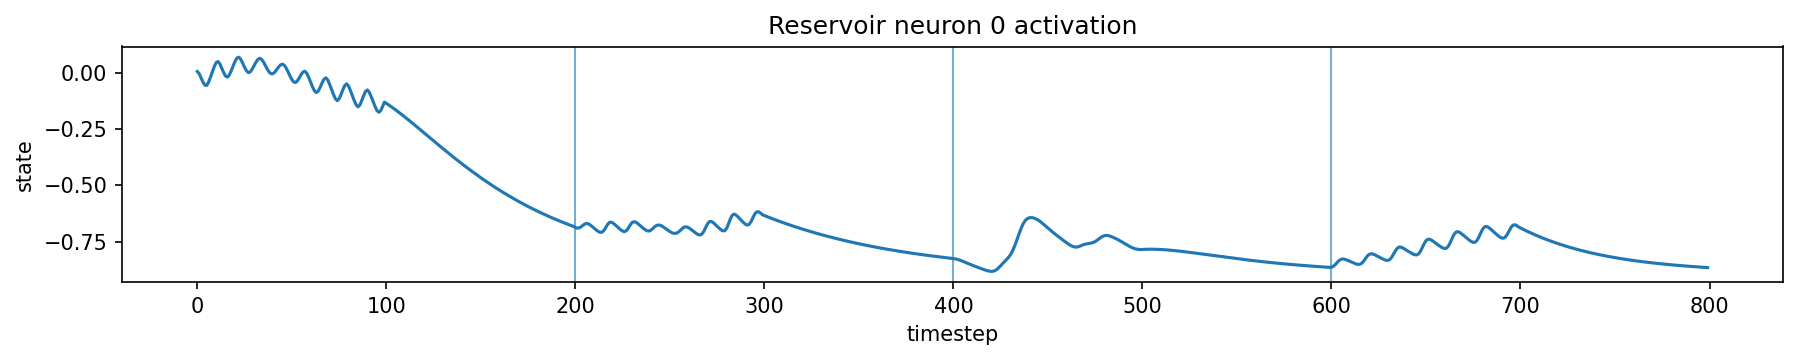

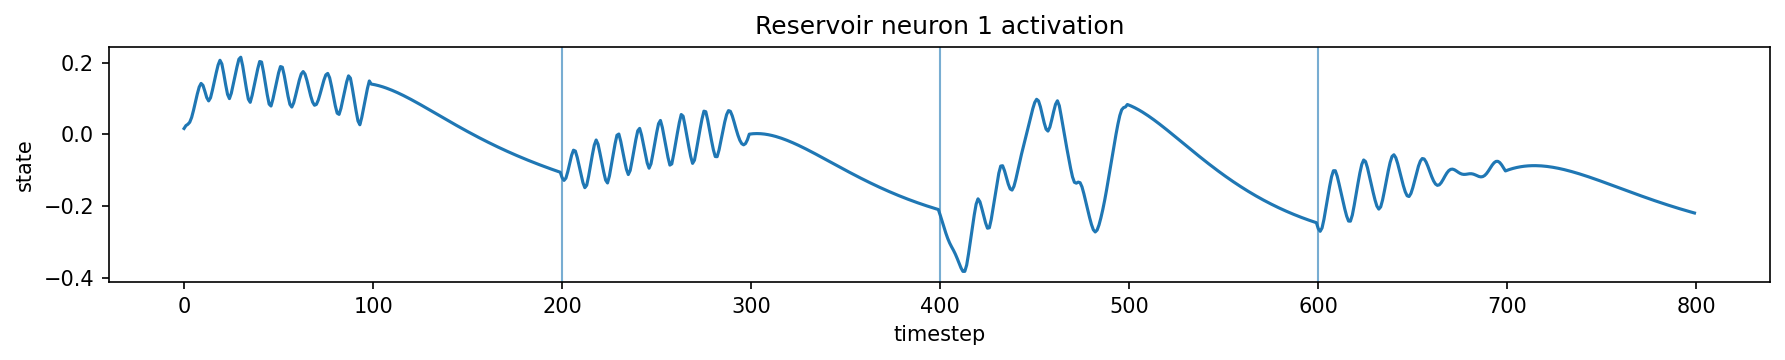

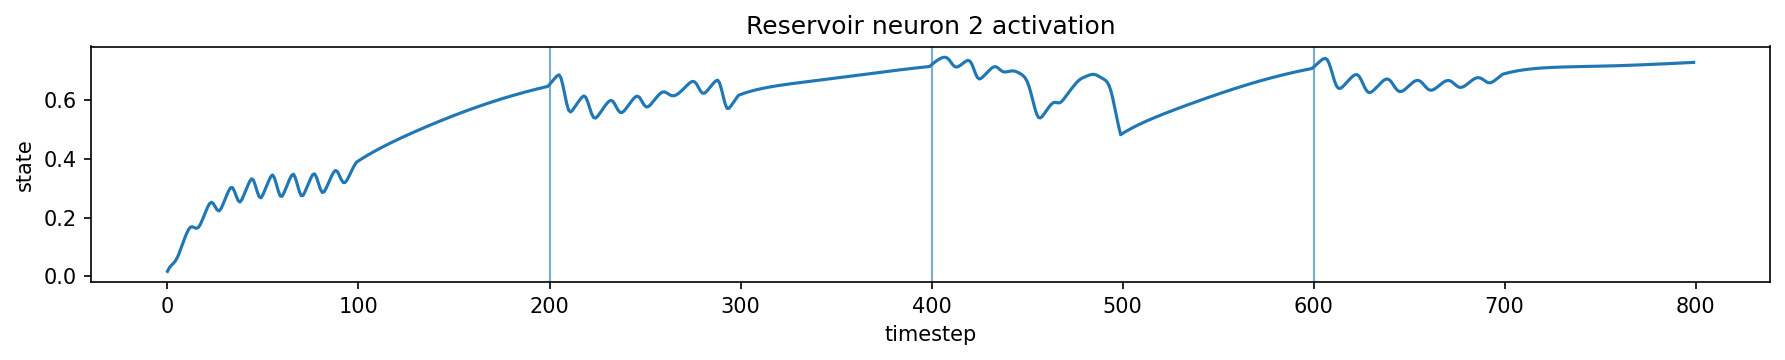

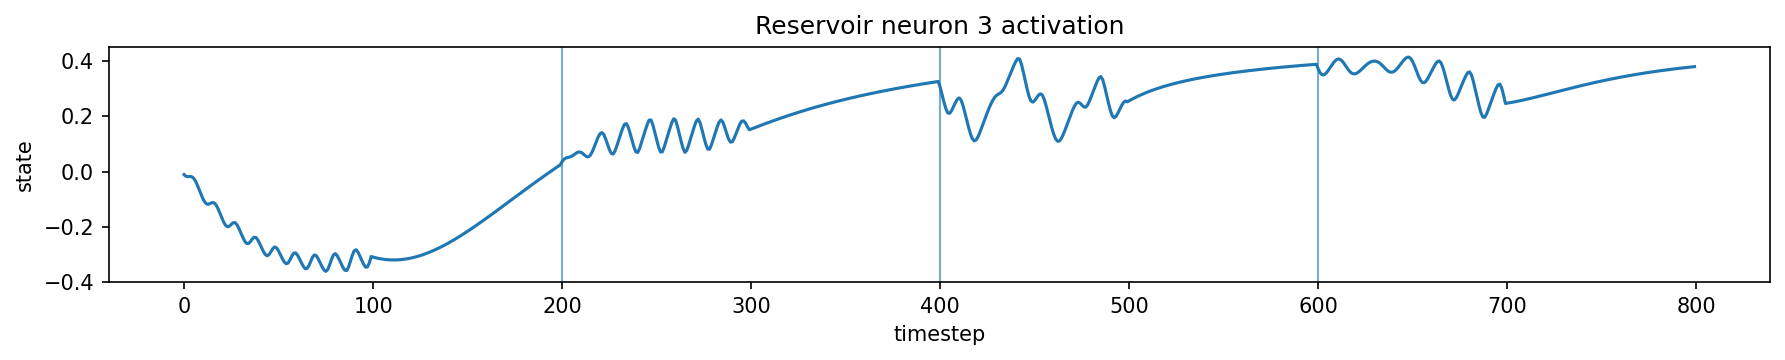

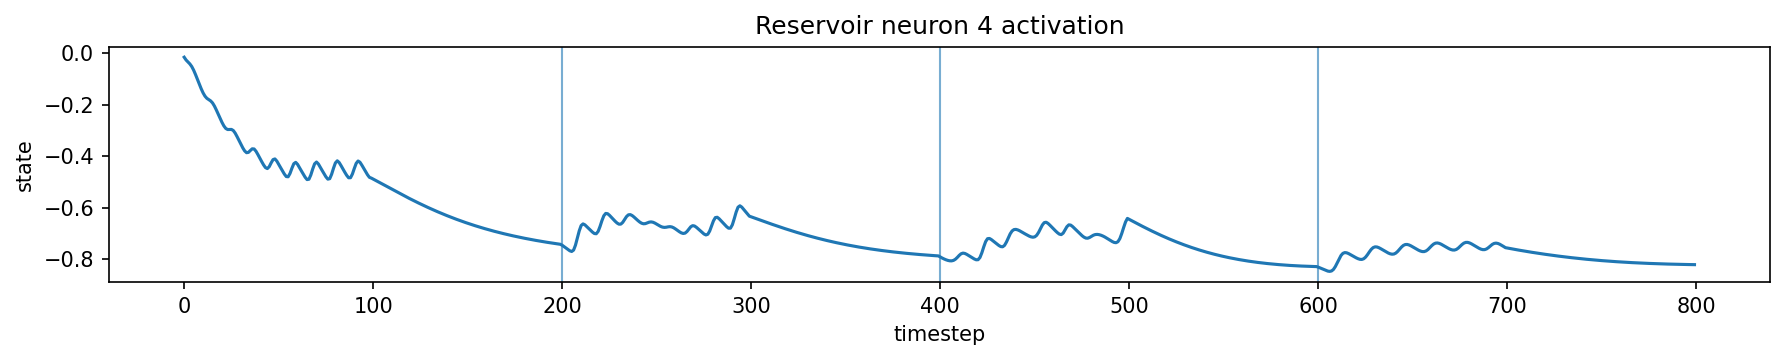

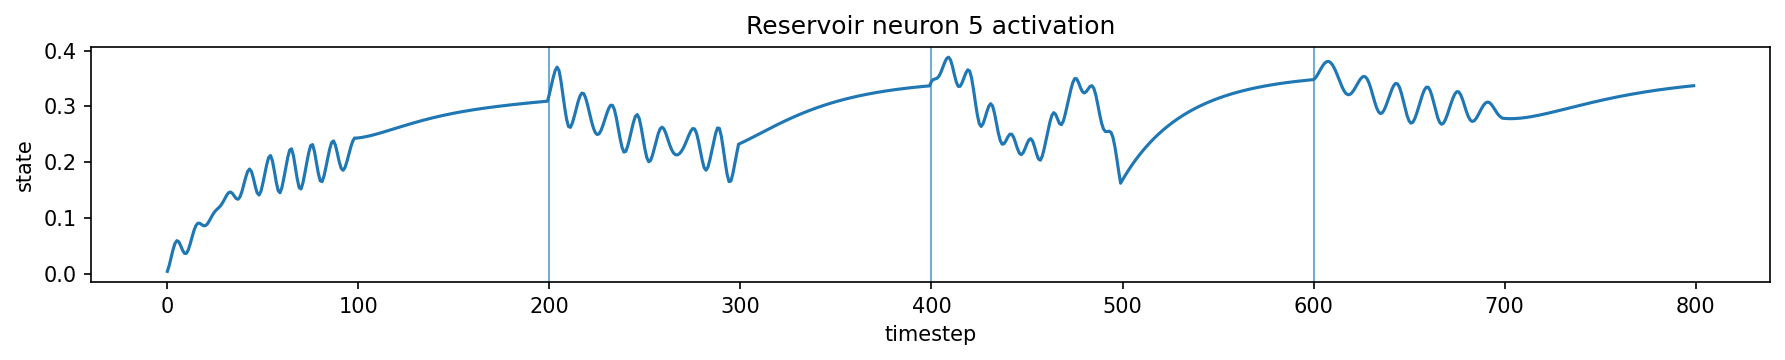

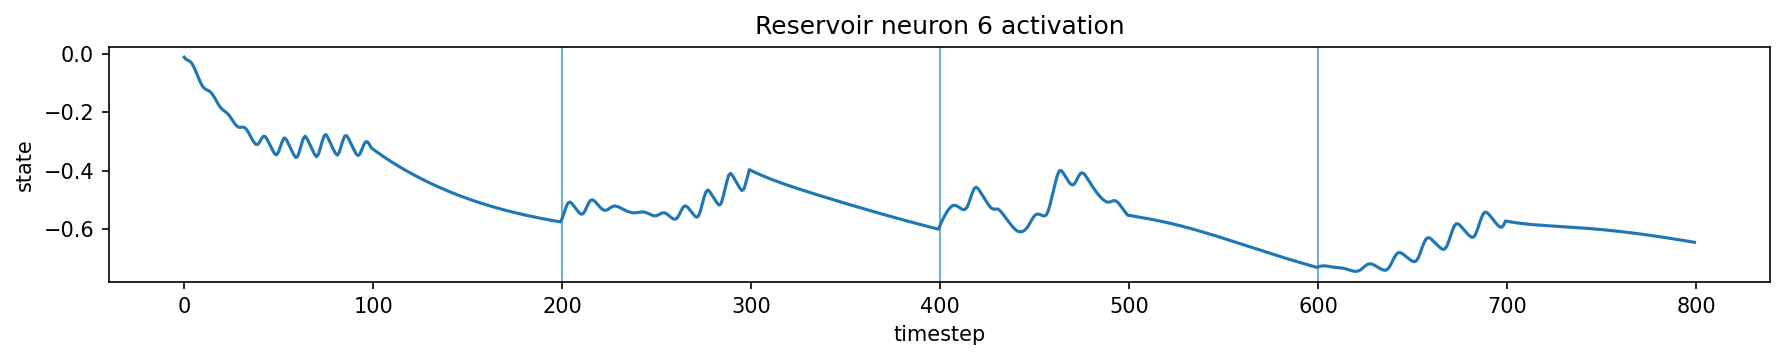

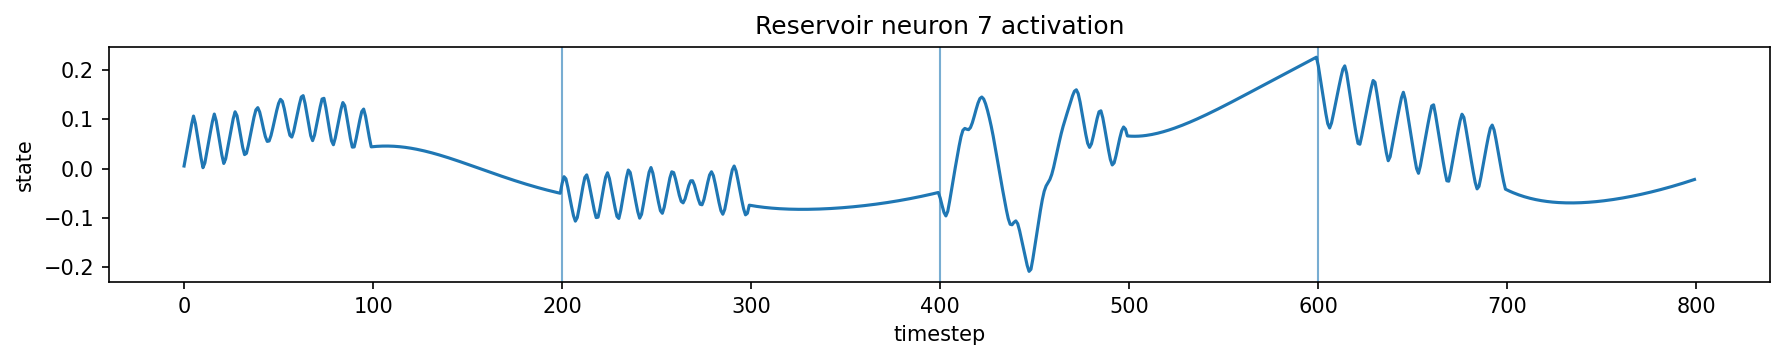

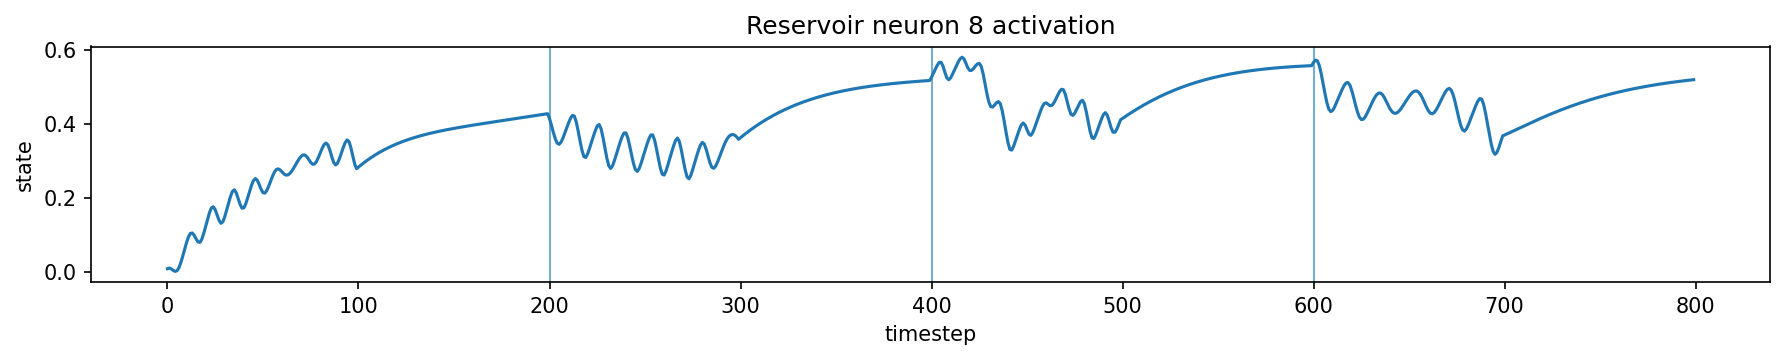

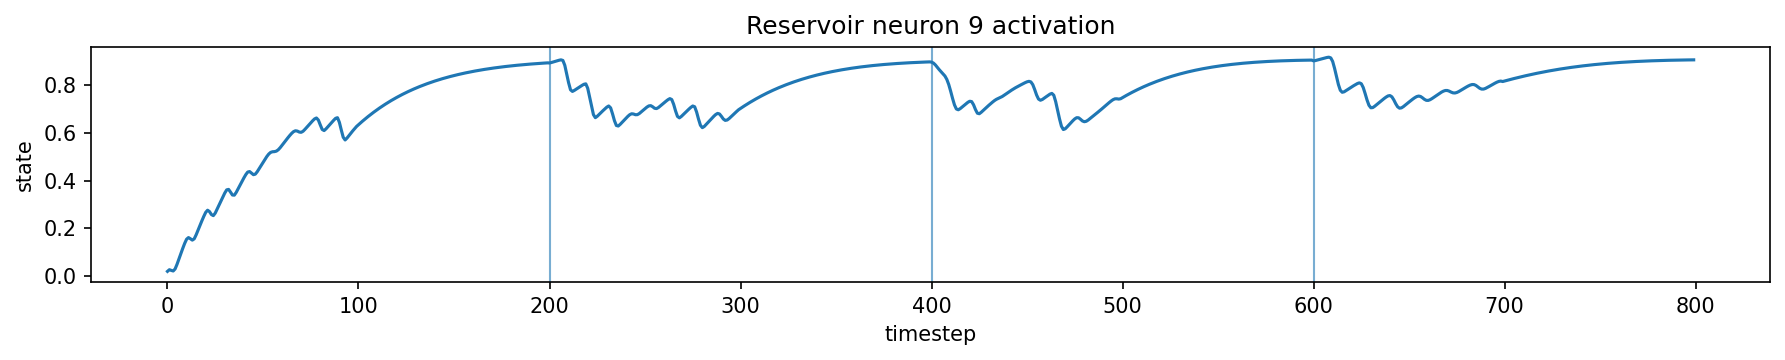

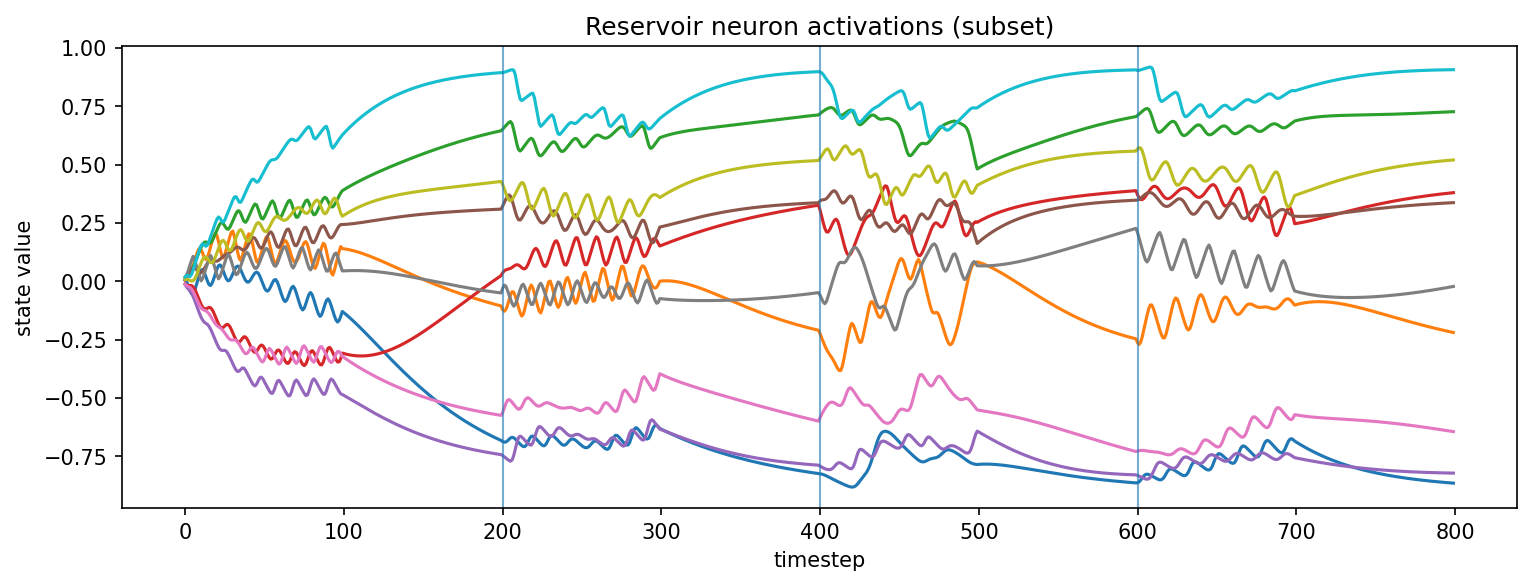

In [32]:
# Visualize reservoir states (track individual neurons)
segment = slice(0, base_delay * num_stimulus)

# Per neuron
for i in range(num_neurons_to_plot):
    plt.figure(figsize=(12, 2.5), dpi=150)
    plt.plot(X_train_stream[segment, i])
    for k in range(1, num_stimulus):
        plt.axvline(k * base_delay, linewidth=1, alpha=0.6)

    plt.title(f"Reservoir neuron {i} activation")
    plt.xlabel("timestep")
    plt.ylabel("state")
    plt.tight_layout()
    plt.show()

# Big graph
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(X_train_stream[segment, :num_neurons_to_plot])
for k in range(1, num_stimulus):
    plt.axvline(k * base_delay, linewidth=1, alpha=0.6)
    plt.title("Reservoir neuron activations (subset)")
    plt.xlabel("timestep")
    plt.ylabel("state value")
plt.show()


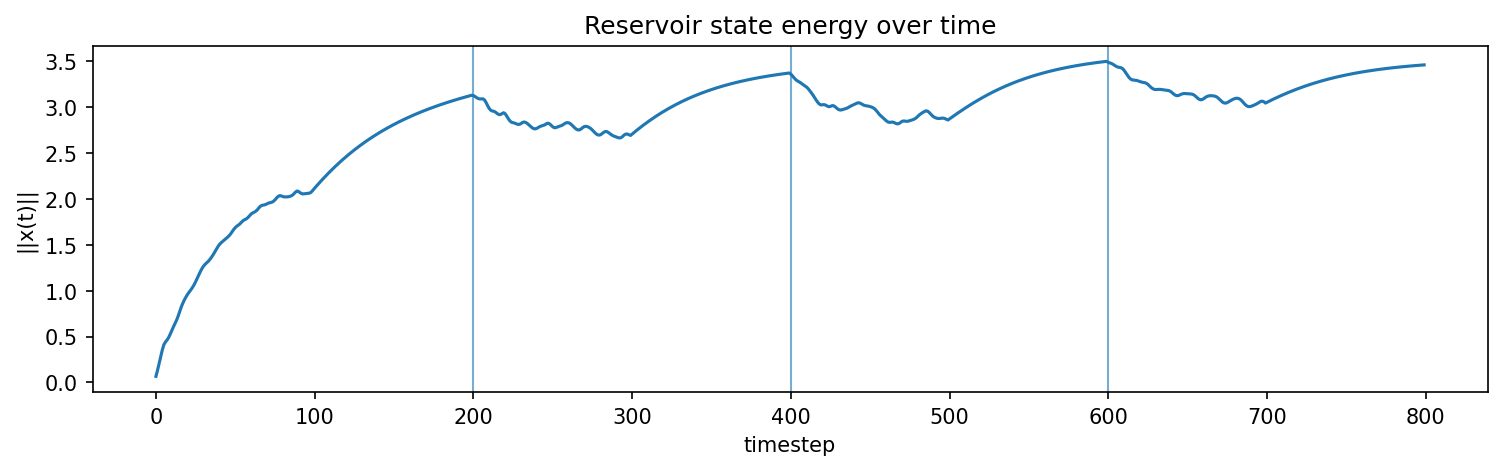

In [33]:
# Reservoir energy (norm of state vector)
energy = np.linalg.norm(X_train_stream, axis=1)

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(energy[segment])
for k in range(1, num_stimulus):
    plt.axvline(k * base_delay, linewidth=1, alpha=0.6)

plt.title("Reservoir state energy over time")
plt.xlabel("timestep")
plt.ylabel("||x(t)||")
plt.show()


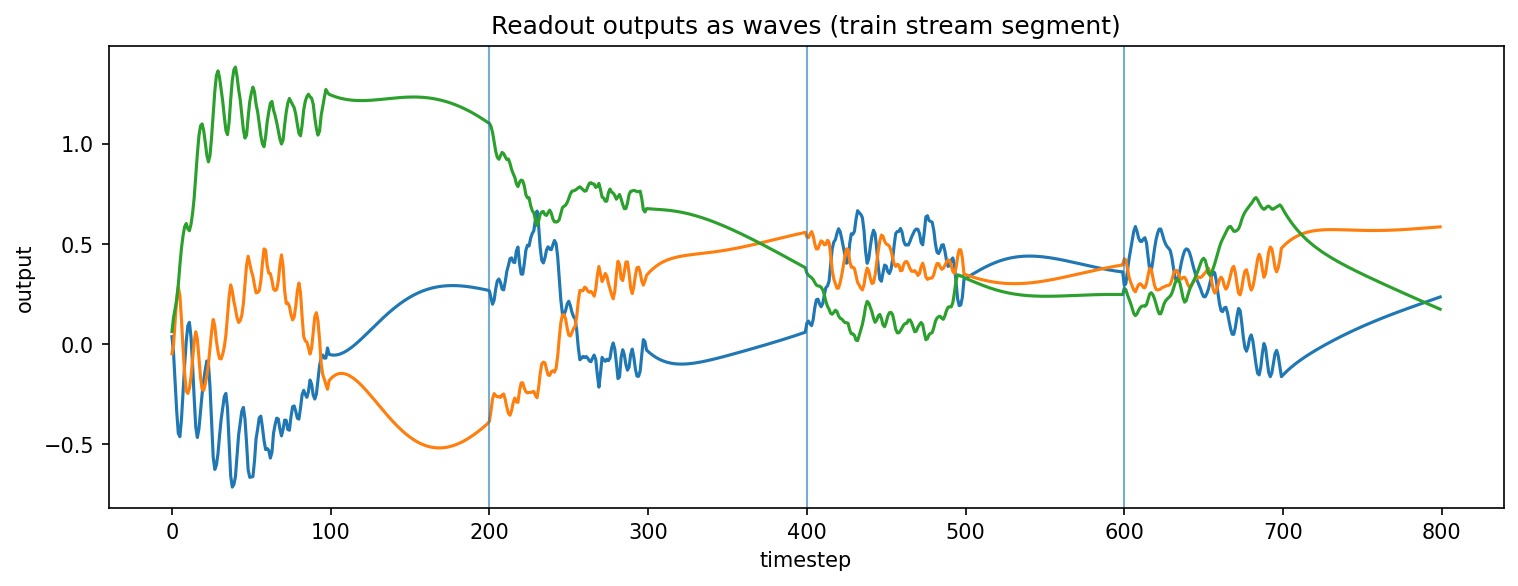

In [34]:
# Visualize output waves (these are huge so todo a better visualization)

segment = slice(0, base_delay * num_stimulus)
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(Y_pred_train[segment])
# stimulus boundaries
for k in range(1, num_stimulus):
    plt.axvline(k * base_delay, linewidth=1, alpha=0.6)
plt.title("Readout outputs as waves (train stream segment)")
plt.xlabel("timestep")
plt.ylabel("output")
plt.show()